In [104]:
from functions_04 import read_gro, midpoints
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [105]:
# Read .gro data
data, title, num_atoms, box_dimensions = read_gro("./data/npt-HK4.gro")

# Dropping velocity components and setting index
data.drop(columns=["Vx", "Vy", "Vz"], inplace=True)  
data.set_index(['res_id', 'atom_name'], inplace=True) 

In [106]:
molecule_10 = data.loc[10][["x", "y", "z"]].values


### Compute oxygen midpoints

In [107]:
midpoints_df = midpoints(data, box_dimensions[0])

In [108]:
mid = midpoints_df[midpoints_df["res_id"] == 1][['mid_x', 'mid_y', 'mid_z']].values

In [109]:
o_atoms = data.reset_index()
o_atoms = o_atoms[o_atoms["atom_name"].isin(["O1", "O2"])]

In [110]:
o = o_atoms[o_atoms["res_id"] == 1][['x', 'y', 'z']].values

In [111]:
np.concatenate((o, mid), axis=0)

array([[ 1.724  ,  0.394  , 10.971  ],
       [ 1.393  ,  0.424  ,  0.12   ],
       [ 1.5585 ,  0.409  , 11.16949]])

### Alpha shape function

In [112]:
from scipy.spatial import Delaunay
from collections import Counter

def alpha_shape_3D(points, alpha):
    """
    - Compute the alpha shape (concave hull) of a set of 3D points.
    - Returns faces, the indices of points forming the hull surface triangles
    """
    if len(points) < 4:
        raise ValueError("Need at least 4 points for a 3D hull")
    
    tetra = Delaunay(points)
    faces = []

    for simplex in tetra.simplices:
        # Vertices of the tetrahedron
        pts = points[simplex]
        
        # Compute circumsphere radius
        A = np.hstack((2*(pts - pts[0]), np.ones((4,1))))
        b = np.sum(pts**2 - pts[0]**2, axis=1)
        try:
            x = np.linalg.lstsq(A, b, rcond=None)[0]
            center = x[:-1] + pts[0]
            r2 = np.sum((pts[0] - center)**2)
        except np.linalg.LinAlgError:
            continue
        
        if r2 < (1.0/alpha)**2:
            # Add boundary faces (each tetra has 4 faces)
            for i in range(4):
                face = tuple(sorted(simplex[np.arange(4) != i].astype(np.int64)))
                faces.append(face)
    
    # Remove internal faces (those appearing twice)
    face_count = Counter(faces)
    hull_faces = [f for f, c in face_count.items() if c == 1]
    
    
    return hull_faces

In [113]:
import trimesh

trimesh_arr = np.zeros((len(data.index.levels[0]),2),dtype=object)
# Make trimesh_arr with trimesh object for all molecules
for res_id in data.index.levels[0]:
    molecule = data.loc[res_id][['x','y','z']].values
    temp = trimesh.Trimesh(vertices = molecule, faces = alpha_shape_3D(molecule, alpha = 0.08)) #change alpha here when learn how to optimize alpha
    trimesh_arr[res_id - 1] = [res_id,temp]

trimesh_arr

array([[1,
        <trimesh.Trimesh(vertices.shape=(37, 3), faces.shape=(72, 3))>],
       [2,
        <trimesh.Trimesh(vertices.shape=(42, 3), faces.shape=(80, 3))>],
       [3,
        <trimesh.Trimesh(vertices.shape=(33, 3), faces.shape=(64, 3))>],
       ...,
       [1499,
        <trimesh.Trimesh(vertices.shape=(31, 3), faces.shape=(58, 3))>],
       [1500,
        <trimesh.Trimesh(vertices.shape=(37, 3), faces.shape=(72, 3))>],
       [1501,
        <trimesh.Trimesh(vertices.shape=(23, 3), faces.shape=(44, 3))>]],
      shape=(1501, 2), dtype=object)

In [114]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd())))
if project_root not in sys.path:
    sys.path.append(project_root)

from utils import subbox_division as sd
subboxes = sd.subbox_division(1501, box_dimensions, midpoints_df)
subboxes = sd.flatten_subboxes(subboxes)

subboxes

,select_index,nearby_res_id
0,"1,1,1","[102, 853, 293, 1014, 325, 660, 226, 513, 897,..."
1,"1,1,10","[438, 1013, 102, 853, 195, 1322, 492, 1037, 69..."
2,"1,1,11","[1013, 102, 853, 293, 1014, 195, 1322, 691, 66..."
3,"1,1,2","[293, 1014, 325, 1057, 226, 513, 897, 1202, 70..."
4,"1,1,3","[325, 619, 1299, 1057, 513, 897, 1202, 703, 25..."
...,...,...
1326,"9,9,5","[712, 1026, 1178, 719, 836, 275, 1205, 710, 46..."
1327,"9,9,6","[836, 275, 1205, 1405, 710, 467, 1325, 687, 25..."
1328,"9,9,7","[1222, 1483, 275, 1205, 1405, 467, 1325, 256, ..."
1329,"9,9,8","[1222, 1483, 923, 1405, 814, 1325, 166, 571, 8..."


In [115]:
subboxes.values

array([['1,1,1',
        list([np.int64(102), np.int64(853), np.int64(293), np.int64(1014), np.int64(325), np.int64(660), np.int64(226), np.int64(513), np.int64(897), np.int64(1202), np.int64(3), np.int64(1380), np.int64(2), np.int64(4), np.int64(1343), np.int64(1206), np.int64(1330), np.int64(192), np.int64(1349), np.int64(164), np.int64(244), np.int64(847), np.int64(359), np.int64(247)])],
       ['1,1,10',
        list([np.int64(438), np.int64(1013), np.int64(102), np.int64(853), np.int64(195), np.int64(1322), np.int64(492), np.int64(1037), np.int64(691), np.int64(660), np.int64(453), np.int64(231), np.int64(2), np.int64(586), np.int64(1046), np.int64(1343), np.int64(818), np.int64(503), np.int64(610), np.int64(1487), np.int64(164), np.int64(244)])],
       ['1,1,11',
        list([np.int64(1013), np.int64(102), np.int64(853), np.int64(293), np.int64(1014), np.int64(195), np.int64(1322), np.int64(691), np.int64(660), np.int64(226), np.int64(3), np.int64(231), np.int64(2), np.int64(4

In [130]:
from trimesh.collision import CollisionManager

def is_blocked(meshes, idx_A, idx_B, step=0.1):
    """
    Check if molecule A is blocked from seeing molecule B by other molecules.
    meshes: list or array of trimesh.Trimesh objects
    idx_A, idx_B: indices of source and target molecules
    step: step size along the line of sight
    """
    def get_mesh_by_id(meshes, idx):
        for mol_id, mol in meshes:
            if mol_id == idx:
                return mol
        raise ValueError(f"Mesh with id {idx} not found")
    
    def walk_and_check(start_idx, end_idx):
        mol_start = get_mesh_by_id(meshes, start_idx)
        mol_end = get_mesh_by_id(meshes, end_idx)
        
        # centroids
        p_start = mol_start.centroid
        p_end = mol_end.centroid

        # direction vector
        vec = p_end - p_start
        dist = np.linalg.norm(vec)
        direction = vec / dist

        mol_copy = mol_start.copy()

        # build collision manager once (all except start/end)
        manager = CollisionManager()
        for mol_id, mol in meshes:
            if mol_id in (start_idx, end_idx):
                continue
            try:
                manager.add_object(name=f"mol{mol_id}",mesh=mol)
            except:
                # print(f"fails at {mol_id}")
                pass

        # march along line
        # print(p_end, p_start)
        try:
            num_steps = int(dist / step)
        except:
            # print(f"fail at {(start_idx, end_idx)}")
            return True
        
        for _ in range(num_steps):  
            mol_copy.apply_translation(direction * step)
            if manager.in_collision_single(mol_copy):
                return True  # blocked!
            
        return False # not blocked



            # # check against all other molecules
            # for j, mol in enumerate(meshes):
            #     if j in (start_idx, end_idx):
            #         continue
            #     if not mol_copy.intersection(mol).is_empty:
            #         return True   # blocked!
    return walk_and_check(idx_A,idx_B) or walk_and_check(idx_B,idx_A)


In [117]:
mask = np.isin(trimesh_arr[:,0], 1380)
temp = trimesh_arr[mask]
temp

array([[1380,
        <trimesh.Trimesh(vertices.shape=(28, 3), faces.shape=(52, 3))>]],
      dtype=object)

In [ ]:
# Blocking algo
import itertools
edges = []


for index, nearby_res in subboxes.values:
    mask = np.isin(trimesh_arr[:,0], nearby_res)
    nearby_trimesh_arr = trimesh_arr[mask]
    for pair in itertools.combinations(nearby_res,2):
        # print(pair)
        if is_blocked(nearby_trimesh_arr,pair[0],pair[1]):
            # print(f"{pair}blocked")
            continue
        else:
            edges.append(pair)

edges
  
    


c:\Users\user\anaconda3\envs\kmc\Lib\site-packages\trimesh\base.py:612: RuntimeWarning: Mean of empty slice.
  centroid = self.triangles_center.mean(axis=0)
c:\Users\user\anaconda3\envs\kmc\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


KeyboardInterrupt: 

### Animation

In [10]:
def alpha_ani(points, faces, oxygens, midpoint, save = None, writer="pillow"):
    # Create figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot points
    ax.scatter(points[:,0], points[:,1], points[:,2], color="k", s=20)

    # Plot hull
    faces_list = [points[list(face)] for face in faces]
    poly3d = Poly3DCollection(faces_list, alpha=0.3, facecolor="cyan", edgecolor="k")
    ax.add_collection3d(poly3d)

    # Plot oxygens and midpoints
    pts = np.concatenate((oxygens, midpoint))
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], color="red", s=20)

    # Set equal aspect ratio for the 3D axes
    ax.set_box_aspect([1,1,1])  

    # Animation: rotate the camera
    def rotate(angle):
        ax.view_init(elev=30, azim=angle)

    anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

    plt.show()

    # Save as GIF
    if save != None:
        anim.save(f"./animation/{save}", writer, fps=20)


In [11]:
alpha_ani(
    points = molecule_10, 
    faces = alpha_shape_3D(molecule_10, alpha=0.1), 
    midpoint = midpoints_df.loc[9].values[1:],
    save = "oooo.mp4", 
    writer="ffmpeg"
    )

TypeError: alpha_ani() missing 1 required positional argument: 'oxygens'

## PBC problem for alpha shape

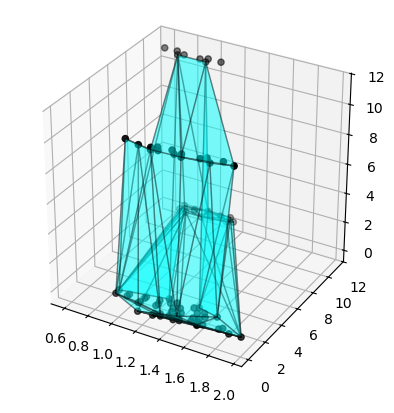

In [ ]:
molecule_1 = data.loc[1][["x", "y", "z"]].values

alpha_ani(
    points = molecule_1, 
    faces = alpha_shape_3D(molecule_1, alpha=0.1), 
    save = "broken_pbc.mp4", 
    writer="ffmpeg"
    )

In [ ]:
def unwrap_points(points, box_length):
    """
    Unwrap molecule coordinates using the Minimum Image Convention.

    Returns
    -------
    unwrapped : (n,3) array
        Coordinates unwrapped relative to the first atom
    """
    unwrapped = np.zeros_like(points)
    unwrapped[0] = points[0]  # reference atom
    
    for i in range(1, len(points)):
        delta = points[i] - points[i-1]
        # apply MIC shift
        delta -= box_length * np.round(delta / box_length)
        unwrapped[i] = unwrapped[i-1] + delta
    
    return unwrapped

def alpha_shape_3D_pbc(points, alpha, box_length):
    """
    Compute alpha shape of molecule under PBC.
    """
    # unwrap molecule coordinates
    unwrapped = unwrap_points(points, box_length)
    
    # compute alpha shape on unwrapped coordinates
    faces = alpha_shape_3D(unwrapped, alpha)
    
    return faces, unwrapped


In [ ]:
molecule_11 = data.loc[11][["x", "y", "z"]].values

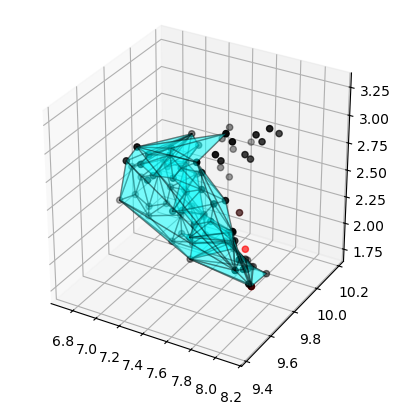

In [ ]:
alpha_ani(
    points = alpha_shape_3D_pbc(molecule_11, 0.08, box_dimensions[0])[1], 
    faces = alpha_shape_3D_pbc(molecule_11, 0.08, box_dimensions[0])[0],
    oxygens = o_atoms[o_atoms["res_id"] == 11][['x', 'y', 'z']].values,
    midpoint = midpoints_df[midpoints_df["res_id"] == 11][['mid_x', 'mid_y', 'mid_z']].values,
    save = "alpha_pbc_ani2.mp4", 
    writer="ffmpeg"
    )

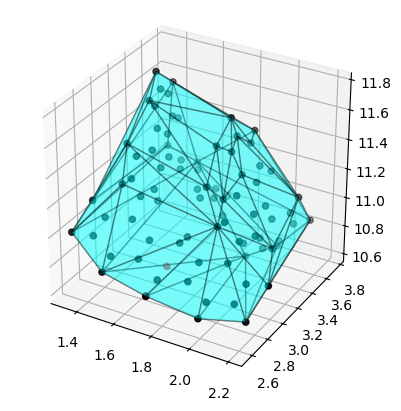

In [ ]:
molecule_110 = data.loc[110][["x", "y", "z"]].values

alpha_ani(
    points = alpha_shape_3D_pbc(molecule_110, 0.08, box_dimensions[0])[1], 
    faces = alpha_shape_3D_pbc(molecule_110, 0.08, box_dimensions[0])[0],
    oxygens = o_atoms[o_atoms["res_id"] == 110][['x', 'y', 'z']].values,
    midpoint = midpoints_df[midpoints_df["res_id"] == 110][['mid_x', 'mid_y', 'mid_z']].values,
    save = "alpha_pbc_ani3.mp4", 
    writer="ffmpeg"
    )

In [ ]:
box_dimensions

[11.24798, 11.24798, 11.24798]

## Ray-triangle intersection

In [ ]:
def ray_triangle_intersect(p0, d, v0, v1, v2):
    """
    Möller–Trumbore ray-triangle intersection.
    
    p0 : (3,) array - ray origin
    d  : (3,) array - ray direction (not necessarily normalized)
    v0,v1,v2 : (3,) arrays - triangle vertices
    
    Returns
    -------
    (t,u,v) if intersect, else None
    where intersection point = p0 + t*d
    """
    eps = 1e-9
    e1 = v1 - v0
    e2 = v2 - v0
    h = np.cross(d, e2)
    a = np.dot(e1, h)

    if -eps < a < eps:
        return None  # parallel
    f = 1.0 / a
    s = p0 - v0
    u = f * np.dot(s, h)

    if u < 0.0 or u > 1.0:
        return None

    q = np.cross(s, e1)
    v = f * np.dot(d, q)

    if v < 0.0 or u + v > 1.0:
        return None
        
    t = f * np.dot(e2, q)

    if t > eps:
        return t, u, v

    return None


def line_intersects_mesh(p0, p1, vertices, faces):
    """Return all intersection points of a line segment with a mesh."""
    d = p1 - p0
    intersections = []
    for face in faces:
        v0, v1, v2 = vertices[list(face)]
        result = ray_triangle_intersect(p0, d, v0, v1, v2)
        if result is not None:
            t, u, v = result
            if 0 <= t <= 1:  # within line segment
                intersections.append(p0 + t*d)
    return intersections


In [ ]:
# Define triangle
v0 = np.array([0, 0, 0])
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])

# Define line segment
p0 = np.array([0.2, 0.2, -1])   # start point
p1 = np.array([0.2, 0.2,  1])   # end point
d = p1 - p0

# Compute intersection
result = ray_triangle_intersect(p0, d, v0, v1, v2)
if result is not None:
    t, u, v = result
    intersection = p0 + t * d
    print("Intersection point:", intersection)
else:
    print("No intersection")

Intersection point: [0.2 0.2 0. ]


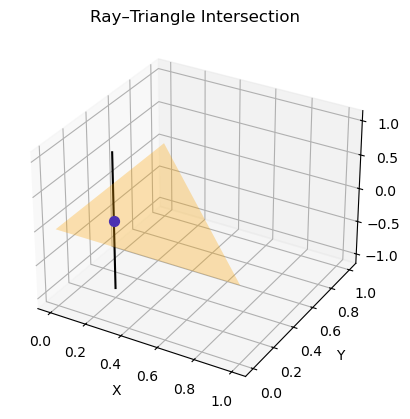

In [ ]:
# --- Visualization ---
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot triangle
triangle = [v0, v1, v2]
ax.add_collection3d(Poly3DCollection([triangle], alpha=0.3, facecolor="orange"))

# Plot line segment
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color="k")

# Plot intersection point
if intersection is not None:
    ax.scatter(intersection[0], intersection[1], intersection[2], color="blue", s=50)

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Ray–Triangle Intersection")

plt.show()

Intersections found: [array([0.3, 0.3, 0. ]), array([0.3, 0.3, 1. ]), array([0.3, 0.3, 2. ])]


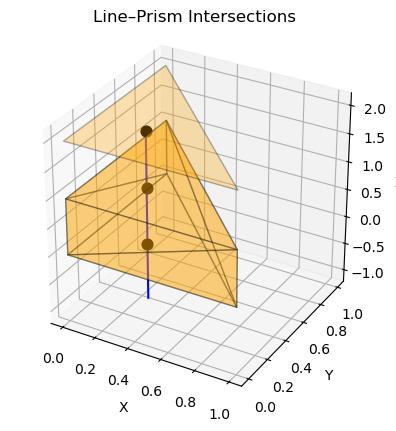

In [ ]:
# Triangular prism example
vertices = np.array([
    [0, 0, 0],   # 0
    [1, 0, 0],   # 1
    [0, 1, 0],   # 2
    [0, 0, 1],   # 3
    [1, 0, 1],   # 4
    [0, 1, 1],   # 5
    [0,0,2],[1,0,2],[0,1,2]
])

faces = [
    # bottom triangle
    (0,1,2),
    # top triangle
    (3,5,4),
    # three rectangular sides split into triangles
    (0,1,4), (0,4,3),  # side 1
    (1,2,5), (1,5,4),  # side 2
    (2,0,3), (2,3,5),  # side 3

    # another plane
    (6,7,8)
]

# Define line segment passing through prism
p0 = np.array([0.3, 0.3, -1])  # start below
p1 = np.array([0.3, 0.3,  2])  # end above

# Compute intersections
intersections = line_intersects_mesh(p0, p1, vertices, faces)
print("Intersections found:", intersections)

# --- Visualization ---
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot prism surface
poly_faces = [[vertices[idx] for idx in face] for face in faces]
ax.add_collection3d(Poly3DCollection(poly_faces, alpha=0.3, facecolor="orange", edgecolor="k"))

# Plot line
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color="blue")

# Plot intersections
for point in intersections:
    ax.scatter(point[0], point[1], point[2], color="k", s=60)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Line–Prism Intersections")

# Set equal aspect ratio for the 3D axes
ax.set_box_aspect([1,1,1])  

# Animation: rotate the camera
def rotate(angle):
    ax.view_init(elev=30, azim=angle)

anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

plt.show()

anim.save("./animation/line_prism.mp4", writer="ffmpeg", fps=30)        